In [1]:
#Setup and Imports
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
#Problem Interface
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


In [3]:
#Node Class
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:

#Helper Functions
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions

def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


In [5]:

#Grid Problem from A

#Implemenenting the grid search problem

MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        row,col = state

          #Checking UP
        new_row= row-1
        new_col=col
        new_state = (new_row,new_col)
        if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append("UP")

          #Checking DOWN
        new_row= row+1
        new_col=col
        new_state = (new_row,new_col)
        if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append("DOWN")

          #Checking LEFT
        new_row= row
        new_col=col-1
        new_state = (new_row,new_col)
        if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append("LEFT")

          #Checking RIGHT
        new_row= row
        new_col=col+1
        new_state = (new_row,new_col)
        if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append("RIGHT")


        # 3. Return legal_actions.
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row,col = state

        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        if action == "UP":
          return (row-1,col)
        elif action == "DOWN":
          return (row + 1,col)
        elif action == "LEFT":
          return (row,col-1)
        elif action == "RIGHT":
          return (row,col+1)
        else:
          raise ValueError(f"Unknown action: {action}")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1.0



#Shared expand Method
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        #--I'm finding the current position in the problem the state
        #--Store it in s

        # s <- node.STATE
        s = node.state
        # for each action in problem.ACTIONS(s):
        # s_prime <- problem.RESULT(s, action)

        for action in problem.actions(s):
              s_prime = problem.result(s,action)

         #cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)

              cost = node.path_cost + problem.action_cost(s,action,s_prime)

        # yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
              yield Node(state = s_prime,parent = node, action = action ,path_cost =cost)


    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass



In [6]:
#Visualisation Helper
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()




In [7]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        # 2. Return self.terrain_costs[row][col].
        (row,col) = next_state
        return self.terrain_costs[row][col]


In [8]:
#Self-Check for WeightedGridProblem
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [9]:
#Manhattan_distance
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    (r1,c1) = state
    (r2,c2) = goal
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    return abs(r1 - r2) + abs(c1-c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    #
    # Hint: math.sqrt(...) or math.dist(state, goal).
    return math.dist(state,goal)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [10]:
#Self-Check for Heuristics
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [11]:
#The Priority-Queue Frontier
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [12]:
#Best-First Search

class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        node = Node(problem.initial_state())
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        frontier=PriorityQueue()
        frontier.push(self.evaluation(node,problem),node)
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        reached = {problem.initial_state() : node}
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        nodes_expanded = 0
        max_frontier_size = 1
        # 5. While the frontier is not empty:
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.
        while frontier:
          node = frontier.pop()

          if problem.is_goal(node.state):
             return SearchResult(
                  algorithm=self.algorithm_name,
                  status="success",
                  nodes_expanded=nodes_expanded,
                  solution =node,
                  max_frontier_size=max_frontier_size,
                  reached_count=len(reached)
                )
          nodes_expanded += 1

          for child in self.expand(problem, node):
            s = child.state
            if s not in reached or child.path_cost < reached[s].path_cost:
              reached[s] = child
              frontier.push(self.evaluation(child,problem),child)
          max_frontier_size =max(max_frontier_size,len(frontier))
        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            nodes_expanded=nodes_expanded,
            solution =None,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)

        )

In [13]:
#Greedy Best-First Search
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        return self.h(node,problem)


In [14]:
#A* Search

class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
        return self.h(node,problem) + node.path_cost


In [15]:
#Uniform-Cost Search
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [16]:
#Weighted A*
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost + self.weight * self.h(node,problem)

In [17]:
#Self-Check for Algorithms
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [18]:
#Running the algorithms on part A sample map
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18.0,52,5,56
1,A*,success,18,18.0,18,5,23
2,Weighted A* (W=2),success,18,18.0,18,5,23
3,Greedy,success,18,18.0,18,5,23


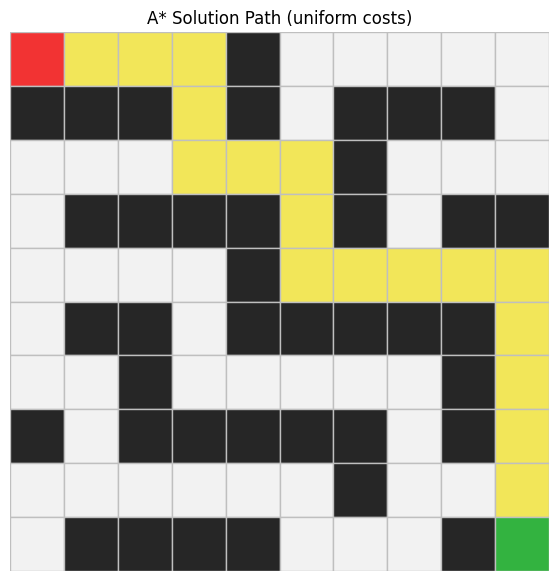

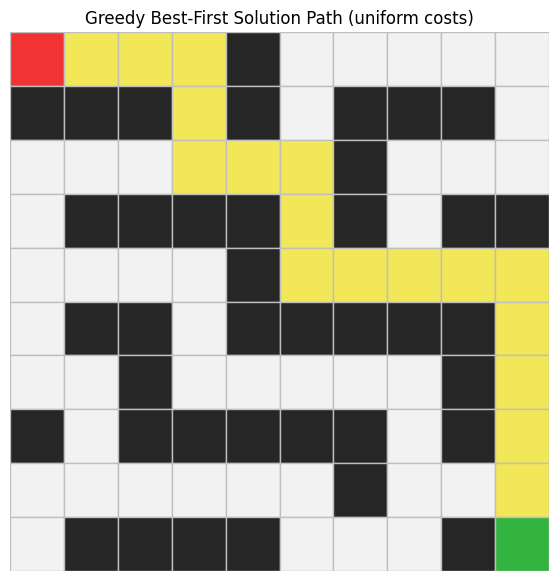

In [19]:
#Visualise two solution paths on the uniform map
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

In [20]:
#Turbulence Map
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


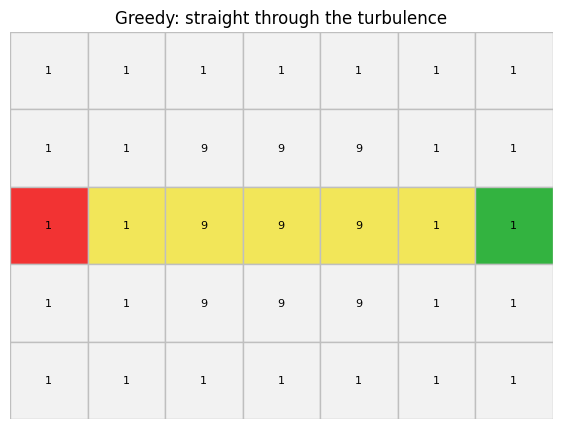

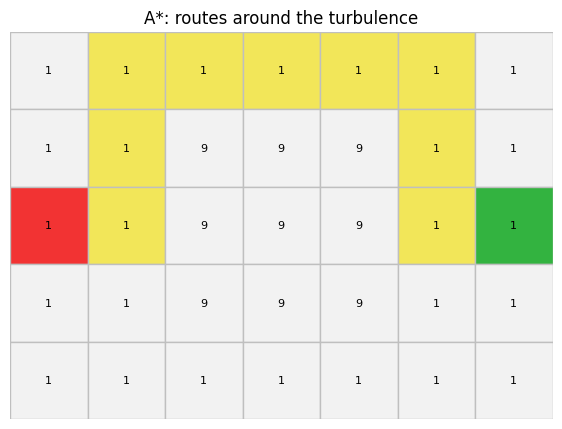

In [21]:
#Greedy vs A* on the turbulence map
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [22]:
#Breaking Admissibility
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h
    def h(state,goal):
      return  factor * manhattan_distance(state,goal)
    return h


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18.0,18,5,23
1,A* inflated x3 (uniform map),success,18,18.0,18,5,23
2,A* admissible (mild turbulence),success,10,10.0,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12.0,6,13,19


#Record of Observation

Record of Observation

1.The inflated heuristic returned a suboptimal path on mild turbulence map by 2 This is  because the solution cost of the admissible A* was 10 and that of the inflated A* was 12.

2.On the turbulence map, inflated A* expanded 6 nodes and admissible A*  expanded 29 nodes. It expanded 23 fewer nodes.

3.An inadmissible heuristic is one that may find suboptimal path faster but expands fewer nodes.As a drone engineer,I would accept this kind of heuristic when there is a real-time constraint like an  emergency response  or when there is limited energy to be consumed by the drone.(Eg: limited battery)

In [23]:
#IDA* Search

#Iterative Deepening A* (IDA*)
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic


    #Helper Method to compute h(n)
    def h(self,node: Node,problem: Problem) -> float:
      return self.heuristic(node.state,problem.goal)

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        # TODO 9 (BONUS, optional):
        # Implement IDA* following the pseudocode guide above.
        #
        # Requirements:
        # 1. Start with limit = h(initial state).

        #Creating an initial node
        initial_node = Node(problem.initial_state())
        #Calculating limit
        #limit <- h(initial)
        limit = self.h(initial_node, problem)

        # 3. Track total nodes_expanded across all iterations and the maximum
        #    recursion depth as max_frontier_size.
        #Tracking total nodes expanded across all iterations
        #Tracking maximum recursion depth reached
        total_nodes_expanded = 0
        max_depth_reached = 0

         # 4. Keep an iteration log of (limit, outcome) pairs in
        #    SearchResult.iterations
        #Storing (limit,outcome) information for each iteration
        #creating an empty list
        iteration_log = []



        # 2. Each iteration performs a recursive f-limited depth-first search
        #    that uses path-cycle checking (reuse the idea from DLS in Part A:
        #    skip a child whose state already appears on the current path).
         # 5. Return status "success", "failure" (next limit is infinity), or
        #    "cutoff" (max_iterations reached).

        for iteration in range(max_iterations):

            #Path cycle checking to prevent revisiting states already on the
            #current path
            path = {initial_node.state}

            #Perform an f-limit DFS search
            result, next_limit, expanded, depth =(
                self._f_limited_search(
                    problem=problem,
                    node=initial_node,
                    limit=limit,
                    path=path,
                )

             )

            #Update total nodes expanded
            total_nodes_expanded += expanded

            #Update max  depth reached
            max_depth_reached= max(max_depth_reached, depth)

            #Returns success if result is a solution node
            if result is not None:

                iteration_log.append(
                    (limit,"success")
                )
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=result,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_depth_reached,
                    reached_count=0,
                    iterations=iteration_log
                )

             #If the next limit is infinity return failure
            if next_limit == float("inf"):
              iteration_log.append(
                  (limit,failure)
              )

              return SearchResult(
                    algorithm=self.algorithm_name,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_depth_reached,
                    reached_count=0,
                    iterations=iteration_log
                )
            #Recording the outcome of the iteration
            iteration_log.append(
                (limit,f"cutoff -> next limit {next_limit}")
            )

            #Change the f-limit and searche again
            limit = next_limit

        #This returns max number of  iterations reached without success and returns cutoff
        return SearchResult(
            algorithm=self.algorithm_name,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_depth_reached,
            reached_count=0,
            iterations=iteration_log
        )
    def _f_limited_search(
        self,
        problem: Problem,
        node: Node,
        limit: float,
        path: set
        ):



        #f <- node.PATH-COST + h(node)
        f = node.path_cost + self.h(node, problem)

        # If f exceeds limit return none
        if f > limit:
            return (None, f, 0, node.depth)

        # a goal test
        if problem.is_goal(node.state):
            return (node, f, 0, node.depth)

        # Expand current node
        nodes_expanded += 1

        #Track deepest recursion depth reached
        max_depth = node.depth

        #next_limit <- infinity
        next_limit = float("inf")

        # Path cycle checking
        for child in self.expand(problem, node):
            # Skips if child state already in path
            if child.state in path:
                continue

            # If not, Add to path and recurse
            path.add(child.state)

            #Recursive depth-first search
            result,new_f,child_expanded,child_depth = (
                self._f_limited_search(
                    problem,
                    child,
                    limit,
                    path
                )

            )

            #Backtrack after recursion returns
            path.remove(child.state)

            # Update nodes_expanded from recursion
            nodes_expanded += child_expanded

            # Update max_depth
            max_depth = max(max_depth,child_depth)

            #If result is the solution return it
            if result is not None:
              return result,new_f,nodes_expanded,max_depth

            #Make the next limit the smallest f that exceeded the current limit
            next_limit = min(next_limit, new_f)
        return None, next_limit,nodes_expanded,max_depth

# After completing the bonus, compare IDA* with A* here:

        ida = IDAStarSearch(manhattan_distance)
        show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

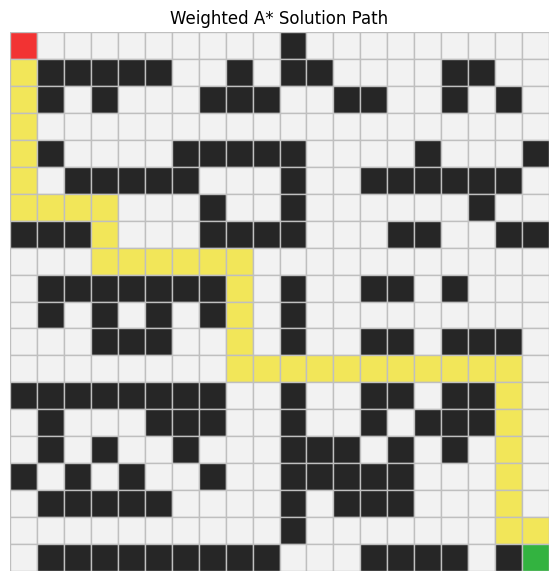

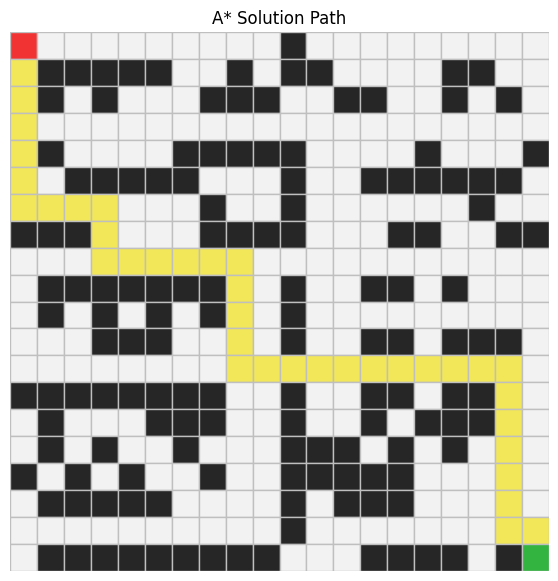

In [24]:
#Create two maps

#A 20 x 20 map
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid.
    [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,0,0,1,0,1,1,0,0,0,0,1,1,0,0],
    [0,1,0,1,0,0,0,1,1,1,0,0,1,1,0,0,1,0,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,0,0,1],
    [0,0,1,1,1,1,1,0,0,0,1,0,0,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0],
    [1,1,1,0,0,0,0,1,1,1,1,0,0,0,1,1,0,0,1,1],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,0,0,1,0,0,1,1,0,1,0,0,0],
    [0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [1,1,1,1,1,1,1,1,0,0,1,0,0,1,1,0,1,1,0,0],
    [0,1,0,0,0,1,1,1,0,0,1,0,0,1,0,1,1,1,0,0],
    [0,1,0,1,0,0,1,0,0,0,1,1,1,0,1,0,1,0,0,0],
    [1,0,1,0,1,0,0,1,0,0,1,1,1,1,1,0,0,0,0,0],
    [0,1,1,1,1,1,0,0,0,0,1,0,1,1,1,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,1,1,0,0,0,1,1,1,1,0,1,0]
]

custom_costs_1 = [
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
    [1,1,1,1,1,1,1,1,1,1,5,1,1,1,1,1,1,1,1,1],
    [1,5,5,5,5,5,1,1,5,1,5,5,1,1,1,1,5,5,1,1],
    [1,5,1,5,1,1,1,5,5,5,1,1,3,3,1,1,5,1,5,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,5,1,1,1,1,5,5,5,5,5,1,1,1,1,5,1,1,1,5],
    [1,1,3,3,3,3,3,1,1,1,5,1,1,3,3,3,3,3,3,1],
    [1,1,1,1,1,1,1,5,1,1,5,1,1,1,1,1,1,5,1,1],
    [5,5,5,1,1,1,1,5,5,5,5,1,1,1,5,5,1,1,5,5],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,5,5,5,5,5,5,5,1,1,5,1,1,5,5,1,5,1,1,1],
    [1,5,1,5,1,5,1,5,1,1,5,1,1,1,1,1,1,1,1,1],
    [1,1,1,5,5,5,1,1,1,1,5,1,1,5,5,1,5,5,5,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [5,5,5,5,5,5,5,5,1,1,5,1,1,5,5,1,5,5,1,1],
    [1,5,1,1,1,5,5,5,1,1,5,1,1,5,1,5,5,5,1,1],
    [1,5,1,5,1,1,5,1,1,1,5,5,5,1,5,1,5,1,1,1],
    [5,1,5,1,5,1,1,5,1,1,5,5,5,5,5,1,1,1,1,1],
    [1,5,5,5,5,5,1,1,1,1,5,1,5,5,5,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,5,1,1,1,1,1,1,1,1,1],
    [1,5,5,5,5,5,5,5,5,5,1,1,1,5,5,5,5,1,5,1],

]

custom_start_1 = (0,0)
custom_goal_1 = (19,19)

# Example after completing:
custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)
custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]
show_results(custom_results_1)

#Visualise Weighted A*

plot_path(

    custom_grid_1,

    custom_start_1,

    custom_goal_1,

    path= custom_results_1[2].path,

    title= "Weighted A* Solution Path",

)





#Visualise A*

plot_path(

    custom_grid_1,

    custom_start_1,

    custom_goal_1,

    path= custom_results_1[1].path,

    title = "A* Solution Path"

)



#Short interpretation depicting which algorithm won and on which metric

Weighted A* won because it achieved the same optimal solution cost of 38 like all the other algorithms . It expanded fewest nodes of 57 to reach the solution. This indicates that Weighted A* was the most efficient because it found the optimal  solution cost like the other algorithms without expanding a lot of nodes.

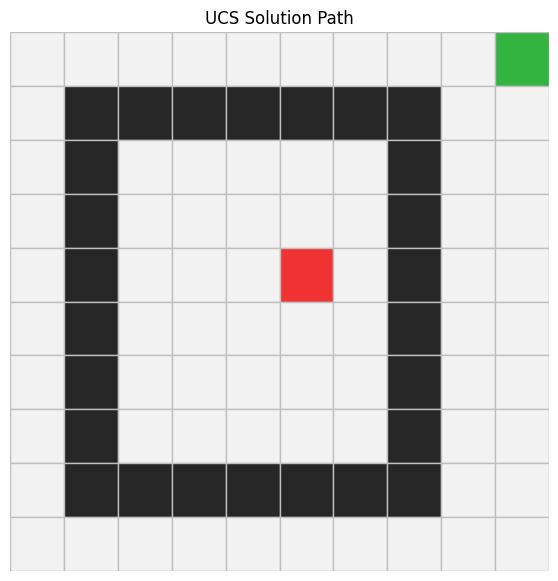

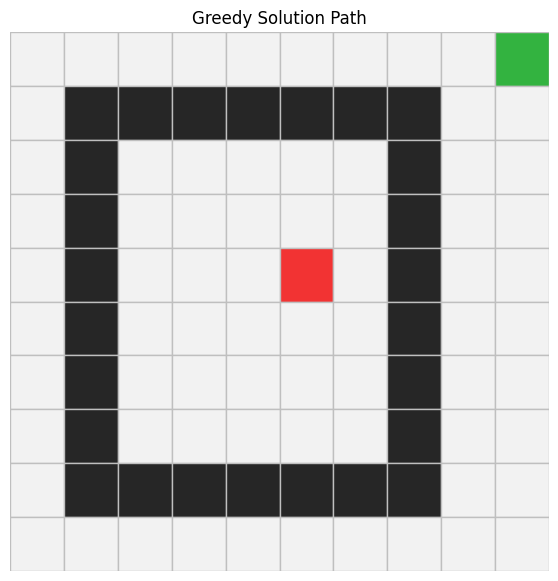

In [25]:
#Create second map
# TODO 11:
# Create your second custom map here.
#A heuristic trap (8 x 8)
custom_grid_2 = [
    # Replace this with your own grid.
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,0,0],
    [0,1,0,0,0,0,0,1,0,0],
    [0,1,0,0,0,0,0,1,0,0],
    [0,1,0,0,0,0,0,1,0,0],
    [0,1,0,0,0,0,0,1,0,0],
    [0,1,0,0,0,0,0,1,0,0],
    [0,1,0,0,0,0,0,1,0,0],
    [0,1,1,1,1,1,1,1,0,0],
    [0,0,0,0,0,0,0,0,0,0],
]

custom_costs_2 = [
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
]

custom_start_2 = (4,5)
custom_goal_2 = (0,9)

# Example after completing:
custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
custom_results_2 = [
   ucs.search(custom_problem_2),
   astar.search(custom_problem_2),
   wastar2.search(custom_problem_2),
   greedy.search(custom_problem_2),
]
show_results(custom_results_2)



#Visualise UCS

plot_path(

    custom_grid_2,

    custom_start_2,

    custom_goal_2,

    path= custom_results_2[0].path,

    title= "UCS Solution Path",

)





#Visualise Greedy

plot_path(

    custom_grid_2,

    custom_start_2,

    custom_goal_2,

    path= custom_results_2[3].path,

    title = "Greedy Solution Path"

)

#Short implementation depicting which algorithm won and on which metric

No algorithm won because  none of them found the solution on the heuristic trap map.They all expanded the same number of nodes of 30 and had no solution cost. This implies that the heuristic trap map can cause informed searches to return failure because the goal can't be reached due to obstacles

#Checkpoint Questions
#Greedy vs A* Analysis
The two solution costs are 30 for greedy and 10 for A*. Yes, A* expanded more nodes than Greedy here."Greedy expanded fewer nodes" is not the same as "Greedy is the better algorithm" because Greedy expanding fewer nodes implies that it was more efficient and used less memory but it produced a higher-cost solution which is 30. For an algorithm to be considered to better it has to use an optimal lower-cost to arrive at the solution.A * used a lower cost but Greedy used a higher cost.


#Reflection Questions
#16.1 Heuristic Functions
#Questions from the main lab

1.Manhattan distance is admissible because its estimate is always less than the actual cost. It is admissible on a 4-connected grid with all terrain costs >=1 becuase it gives the exact number of steps in a relaxed problem and every move costs exactly 1. Since in the 4-connected grid we can only move up,left,down or right and each move costs 1,there may be obstacles but they only add cost. Therefore, it never overestimates.

2. Euclidean distance is admissible because it's a straight line distance and it's always less than Manhattan distance except when they are both zero.Manhattan distance is larger.

3. Manhattan distance wouldn't be admissible if terrain costs were 0.5 because it assumes each step costs 1 or more so if each move costs 0.5 it would cause manhattan to overestimate thus making it inadmissible. This is because ,given Manhattan distance for 4 steps,the actual cost will be 4 × 0.5 which is 2. The Manhattan distance becomes greater than the true cost.That's why the terrain costs must be greater than or equal to 1 to guarantee that it doesn't overestimate.

Actual Reflection Questions

1.h(n) estimates the actual solution cost .That is ,the cost from the current state of the drone to its goal using a given domain.
Its knowledge comes from geometry(GPS coordinates) which tells us positions


2.In the original drone problem,the restrictions were expensive terrain costs,obstacles and varying terrain costs.This relaxation removes the terrain costs,obstacles and set all terrain costs to exactly 1.

3.Manhattan dominates Euclidean because it gives the larger estimate.When a heuristic dominates another it means it gives a bigger estimate of the true cost to reach the goal.It predicts that the number of nodes that will be expabded will be less because the estinate given is a bit closer to the actual cost to the goal.

4..A heuristic is admissible if it doesn't overstimate the actual cost to reach the goal. If the terrain costs is less than 1 it would cause Manhattan distance to overestimate the cost because if the  manhattan distance is 4 and the terrain cost is 0.5. The actual cost will be 2.The Manhattan estinate becomes way bigger than the actual cost. This implies that it overestimates the actual cost causing it to be inadmissible .Therefore the terrain costs must be greater than or equal to 1 to keep Manhattan
admissible.


#16.2 Greedy Best-First Search

1.Greedy ignores the g(n) which is the actual path cost. Greedy found a path cost of 30 through the turbulence while A* found an optimal one of 10 without passing through the turbulence.The turbulence map punished it by having a severe turbulence which has a cost of 9 per cell and it lies directly between the drone and the goal and since  Greedy sees that flying straight reduces the Manhatten distance it goes directly through the turbulence.


2.For an algorithm to be considered as a better one,it must expand fewer nodes and also have a lower path cost .Although greedy expanded fewer nodes of 6 than A* which expanded 25.Its solution cost of 30 was way higher than A* cost of 10 so it cannot be considered to be a better algorithm .


3.A drone's mission where Greedy's behaviour would be acceptable is one where speed is more significant than finding the cheapest solution path.For instance; delivery of medicine as an emergency response.In this situation,arriving to the goal is more important than using a cheaper cost which would save battery or electricity.



#16.3 A* Search
1.f(n) is the drone's total estimated trip cost which is equal to the actual path cost so far g(n) thus the energy used to reach its current position plus the estimated cost to the goal(h(n)).


2.It does that to verify if there is no other node with a lower f(n) which deserves to be expanded and might possibly contain a more better solution cost to the goal.One might end up with a solution cost which isn't optimal.For example, on the turbulence map, the first time a goal is generated might be through the expensive turbulence which would have a solution cost of 30 but A* waits and does a late goal test to find a cheaper path cost.Early goal test would have returned the expensive path as the solution cost.



3.For BFS, the first time we reach a state is always the cheapest so a set is enough.On the other hand, For A* ,a state might be reached multiple times through different paths with different costs so using a dictionary allows us to store the cheapest node for each state and updating it if a better path is found.


4.The nodes expanded by UCS was 52 and that of A* was 18.The heuristic enabled the A* to expand less nodes.The value of the heuristic was admissible.It wasn't overly estimated.The gap shows the value of the Manhattan heuristic which saved 34 expansions by guiding the search toward the goal depicting how a good admissible heuristic reduces the search space.



#16.4 Admissibility and Consistency
1.A heuristic is admissible if it never overestimates the true cost to reach the goal that is,it's always less than or equal to the optimal cost.This guarantees that A* finds the optimal solution.A heuristic is admissible if it satisfies the triangle inequality(h(n) ≤ c(n, a, n') + h(n')) which means that the estimated cost is less than or equal to the action cost plus the estimated cost from the successor node.Consistent implies admissible but admissible does not imply consistent.


2. The experiment confirmed the claim that A* is only guaranteed optimal with an admissible heuristic.With the inflated heuristic,A* found a suboptimal path on the mild turbulence map with a cost of 12 and the optimal cost was 10 although it expanded fewer nodes.This depicts that inadmissible heuristics can be faster but it  can be guaranteed to be optimal.


3.Yes,Manhattan distance is consistent on a unit cost-grid because the triangle inequality is always satisfied.Moving one step changes the Manhattan distance to the goal by at most 1 and the action cost is exactly 1 so h(n) ≤ c(n, a, n') + h(n') is valid.

#16.5 Weighted A* and Trade-offs
1.Weighted A* uses f(n) = g(n) + W*h(n) where W controls how much influence the heuristic has. In UCS; f(n) = g(n) so W is 0 since it doesn't include a heuristic.In A* ,W is 1 because it gives the optimal solution cost with the formula f(n) = g(n) + h(n).With greedy , f(n) = h(n) , W is infinity which implies that as it increases the algorithm becomes more greedy causing it to expand fewer nodes but risking suboptimal paths.

2. Weighted A* guarantees that the solution cost will be no more than W times the optimal cost. So for W = 3, the path will cost at most 3 × optimal cost.On the uniform map, optimal cost was 18, and Weighted A* (W=2) found cost 18 ,it was within bound (18 ≤ 36)
On the turbulence map, optimal cost was 10, and that of Weighted A* was 20 so it was  within bound (10 ≤ 20)
On the mild turbulence map, W=3 (inflated heuristic) found cost 12 while optimal was 10 ,it was also  within the  bound (12 ≤ 30).It can be deduced that the experiments stayed well inside the bound.

3.I would go for Weighted A* with weight of 2 or 3.This is becauses it expands fewer nodes which would save computation time and battery and would still have a solution path which is at most 2 or 3 times optimal.This is because, in this context speed is significant than absolute optimality.

#16.6 Memory and Real-World Drone Context
1.The reached dictionary which stores every state it has seen and the priority queue frontier which stores leaf nodes.IDA* avoids this by using DFS with an f-cost limit instead of a priority queue so it only stores the  current path and not all expanded nodes thus,making it memory efficient.It pays for this by being slower because it re-explores nodes in each iteration.

2.In a real drone application,I would add the following information into the terrain costs.i.Weather conditions like wind speed and rain because flying through a storm would drain the battery faster.  
ii. The state of the battery .This is  because if the drone is low on power it might need to take a shorter path even if it costs more energy per step.
iii. Time of day because flying at night is riskier and might need extra caution.
All  these  would make the terrain costs dynamic and more realistic for the drone.

3.The heuristic breaks if the drone is tracking a moving target since the algorithm plans a pth to where the target was not where it is currently so by the time the drone gets there the target might have changed its state which implies that the solution changes quickly and the drone might never catch up. Concepts like real time search become relevant because the drone would need to replan continuously instead of planning once. Also learned heuristics could help predict the next state of the goal based on its movement pattern.

4.I would ship Weighted A* algorithm on the drone because it balances speed and optimality well.It expands fewer nodes than A* and UCS and it saves computation time and battery.It also gives a guarantee that the solution path cost won't be too expensive. Given a situation where the drone has limited memory ,I would use IDA* instead since it uses less memory.Also in a situation where the environment state is dynamic,I would go for real-time search algorithms because they replan continuously and not once. In a circumstance where the mission is highly significant and path must be very optimal ,I would go for A*.